Modified from "Using Deep Learning for Flexible and Scalable Earthquake Forecasting"  
Reference: [Zenodo](https://zenodo.org/records/8161777)

In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import functools
import os
import importlib
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [2]:
checkpoint_dir = Path("../checkpoints/rtpp_20251204-104931") 
# checkpoints/mixer_tpp_20250912-125450
 # "../checkpoints/mixer_tpp_20250907-112659"
 # /checkpoints/mixer_tpp_20250825-114639 /checkpoints/rtpp_20250824-214315
 # checkpoints/mixer_tpp_20250819-143535 checkpoints/mixer_tpp_20250819-143210
#  checkpoints/rtpp_20250819-142340
checkpoint_path = checkpoint_dir / "last_model_1.pth"

## Loading a trained model

In [3]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint

check_point = torch.load(checkpoint_path,weights_only=False)    
args = load_args_from_checkpoint(None, check_point)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
# model.set_attn_type("flash")
# model.set_attn_dropout(0)
model = torch.compile(model)
model.eval() 

load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'rtpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'bg_model': 'ssm', 'bg_model_cfg': {'d_feature': 1, 'd_state': 128}, 'batch_size': 1, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'none', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'rnn_type': 'GRU', 'd_model': 32, 'rnn_dropout': 0.3, 'num_components': 32, 'dim': 1, 'epochs': 500, 'save_dir': 'checkpoints/rtpp_20251204-104931', 'cuda_id': '0', 'dataset': 'PNR', 'seed': 0, 'minibatch_training': False, 'split_by_time': True, 'time_order': ['train', 'val', 'test'], 'cuda': True, 'tau_mean': 0.06001083552837372, 'tau_min': 5.3589729986924795e-08, 'tau_max': 17.831666946411133, 'tau_q05': 0.002222222276031971, 'tau_q025': 1.189651629829

OptimizedModule(
  (_orig_mod): RecurrentTPP(
    (hypernet_time): Linear(in_features=32, out_features=96, bias=True)
    (hypernet_mag): Linear(in_features=32, out_features=1, bias=True)
    (rnn): GRU(2, 32, batch_first=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (bg_model): SSMBGModel(
      (ssm): SelectiveScanWrapper()
    )
  )
)

In [4]:
from torch.nn.functional import softplus
softplus(model.bg_model.raw_weight)

tensor([[0.6631]], device='cuda:0', grad_fn=<SoftplusBackward0>)

## Loading the catalog

In [5]:
# args.dataset = "ChinaArray" 
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/PNR/raw.


In [6]:
catalog_ds.full_sequence

Sequence(
  inter_times: [22974],
  arrival_times: [22973],
  t_start: 0.0,
  t_end: 1548.0,
  t_nll_start: 0.0,
  mag: [22973],
  loc: [22973, 2],
  depth: [22973],
  time_series: [92316, 1],
  time_series_times: [92316]
)

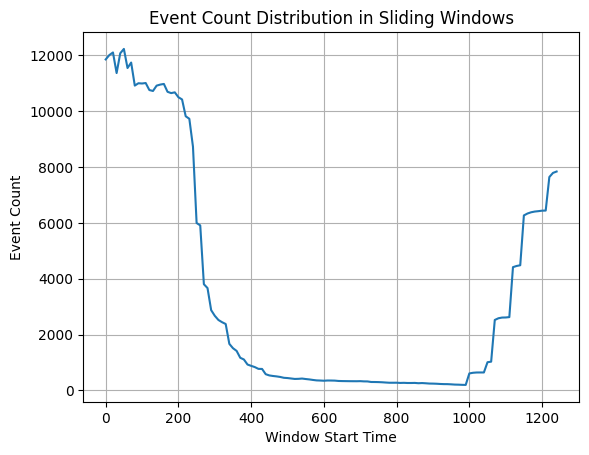

In [7]:
window_size = 300
stride = 10
arrival_times = catalog_ds.full_sequence.arrival_times
max_time = arrival_times.max().item()
window_starts = torch.arange(0, max_time - window_size + stride, stride)
counts = torch.zeros(len(window_starts), dtype=torch.int32)

for i, start in enumerate(window_starts):
    end = start + window_size
    mask = (arrival_times >= start) & (arrival_times < end)
    counts[i] = mask.sum()
plt.plot(window_starts, counts)
plt.xlabel('Window Start Time')
plt.ylabel('Event Count')
plt.title('Event Count Distribution in Sliding Windows')
plt.grid(True)
plt.show()

In [25]:
# b_seq = model.compute_b_value(catalog_ds.full_sequence.to(device),True)
# plt.plot(b_seq.squeeze().detach().cpu().numpy())
# plt.savefig(checkpoint_dir/'b_pred.png')
# data = b_seq.squeeze().detach().cpu().numpy()
# smooth = pd.Series(data).rolling(window=500, min_periods=1).mean()
# plt.plot(smooth)
# plt.savefig(checkpoint_dir/'b_pred_smooth.png')

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

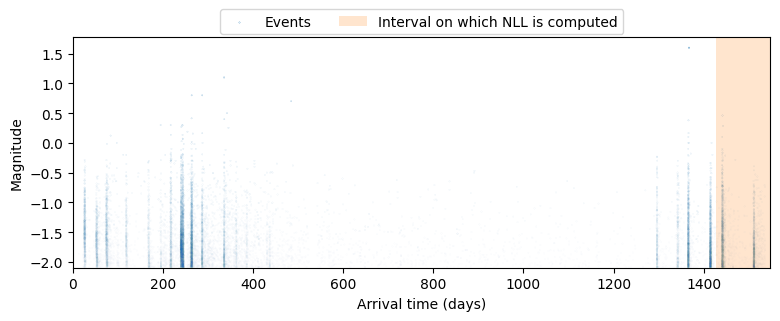

In [9]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
train_seq = catalog_ds.train[0]
visualize_sequence(test_seq, show_nll=True)

We would like to generate a 30-day forecast for the interval `[13000, 13030]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 13000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[13000, 13030]`.

In [10]:
t_forecast = 1460 # 4000 13000
duration = 20 # 7 30
num_samples = 10000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(0, t_forecast) #  3500
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration)

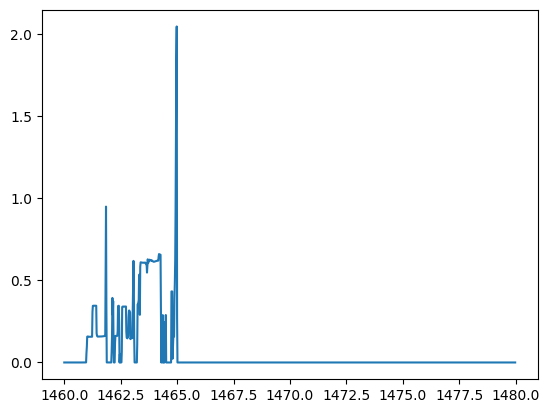

In [11]:
mask  = (test_seq.time_series_times >= t_forecast) & (test_seq.time_series_times < t_forecast + duration)
future_time_series = test_seq.time_series[mask]
future_time_series_times = test_seq.time_series_times[mask]
plt.plot(future_time_series_times, future_time_series.reshape(-1).detach().cpu().numpy())

## Generate the forecast

In [12]:
past_seq.float()

Sequence(
  inter_times: [21423],
  arrival_times: [21422],
  t_start: 0.0,
  t_end: 1460.0,
  t_nll_start: 1428.0,
  mag: [21422],
  loc: [21422, 2],
  depth: [21422],
  time_series: [87601, 1],
  time_series_times: [87601]
)

In [13]:
past_batch = src.data.Batch.from_list([past_seq])

In [14]:
torch.mean(past_batch.inter_times)

tensor(0.0682)

In [15]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

In [16]:
# torch.backends.cudnn.enabled = False

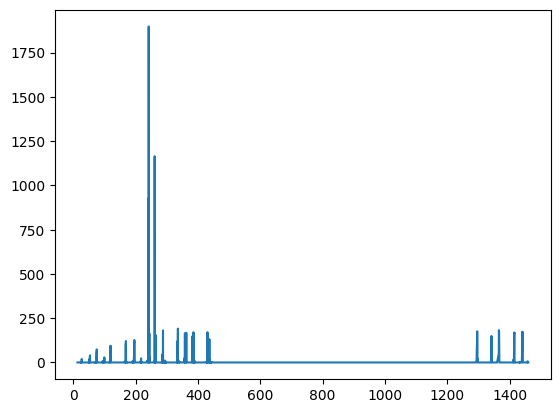

In [ ]:
past_batch.to(device)
ssm_out, out = model.bg_model.intensity(past_batch,return_ssm_out=True)
plt.plot(past_batch.arrival_times.reshape(-1).detach().cpu().numpy(),out.reshape(-1).detach().cpu().numpy())

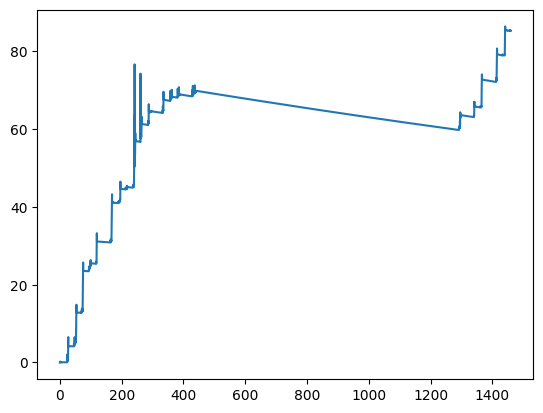

In [24]:
plt.plot(past_batch.time_series_times.squeeze().detach().cpu().numpy(),ssm_out.reshape(-1).detach().cpu().numpy())

In [18]:
model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))

In [19]:
# import torch
# with torch.no_grad():
#     model.bg_model.raw_weight.copy_(torch.tensor([[25.0]], device='cuda'))

In [20]:
set_seed(4) 
model.eval()  # Set the model to evaluation mode

all_forecasts = []
samples_per_batch = 10000
for _ in range(num_samples // samples_per_batch):
    # forecast = model.sample_with_cache(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    # forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, max_sample_len=4000)
    forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    all_forecasts.extend(forecast)

In [21]:
all_forecasts

[Sequence(
   inter_times: [229],
   arrival_times: [228],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [228]
 ),
 Sequence(
   inter_times: [832],
   arrival_times: [831],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [831]
 ),
 Sequence(
   inter_times: [193],
   arrival_times: [192],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [192]
 ),
 Sequence(
   inter_times: [165],
   arrival_times: [164],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [164]
 ),
 Sequence(
   inter_times: [423],
   arrival_times: [422],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [422]
 ),
 Sequence(
   inter_times: [253],
   arrival_times: [252],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [252]
 ),
 Sequence(
   inter_times: [382],
   arrival_times: [381],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [381]
 ),
 Sequence(
   inter_times: 

(array([4.100e+01, 5.270e+02, 1.628e+03, 2.617e+03, 1.959e+03, 1.016e+03,
        6.540e+02, 4.540e+02, 3.430e+02, 2.300e+02, 1.610e+02, 1.130e+02,
        7.300e+01, 4.900e+01, 4.200e+01, 2.900e+01, 1.500e+01, 1.900e+01,
        9.000e+00, 8.000e+00, 6.000e+00, 3.000e+00, 1.000e+00, 1.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([  45.        ,   90.53333333,  136.06666667,  181.6       ,
         227.13333333,  272.66666667,  318.2       ,  363.73333333,
         409.26666667,  454.8       ,  500.33333333,  545.86666667,
         591.4       ,  636.93333333,  682.46666667,  728.        ,
         773.53333333,  819.06666667,  864.6       ,  910.13333333,
         955.66666667, 1001.2       , 1046.73333333, 1092.26666667,
        1137.8       , 1183.33333333, 1228.86666667, 1274.4       ,
        1319.93333333, 1365.46666667, 1411.        ]),
 <BarContainer object of 30 artists>)

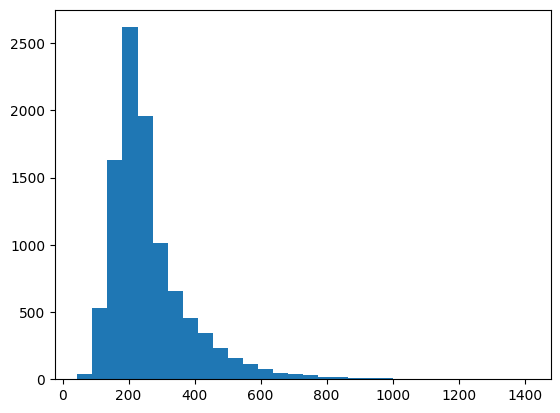

In [22]:
len_list = [len(f.arrival_times) for f in all_forecasts]
plt.hist(len_list, bins=30)

In [23]:
zero_indices = []
for idx, fc in enumerate(all_forecasts):
    t = torch.as_tensor(fc.inter_times).cpu()
    if (t == 0).any():
        zero_indices.append(idx)

if zero_indices:
    print("Found zeros in inter_times at indices:", zero_indices)
else:
    print("No zeros found in inter_times of any forecast.")
print("Number of forecasts with zero inter_times:", len(zero_indices))

Found zeros in inter_times at indices: [320, 472, 3319, 3614, 5914, 6905, 7213, 9030, 9175]
Number of forecasts with zero inter_times: 9


`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[13000, 13030]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

In [24]:
# importlib.reload(src.utils.visualization)

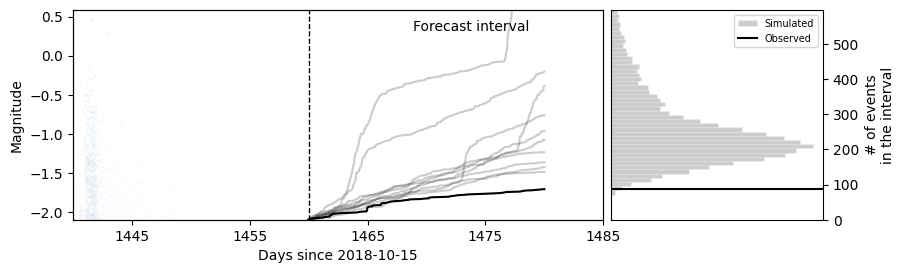

In [25]:
date_str = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d')
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.pdf",figsize=(10,3),xlabel='Days since '+date_str)
# src.utils.visualization.visualize_trajectories(train_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.png")

In [26]:
# src.utils.visualization.plot_counting_process(test_seq)

In [27]:
import  src.utils.catalog_tests as catalog_tests

In [28]:
test_seq

Sequence(
  inter_times: [22974],
  arrival_times: [22973],
  t_start: 0.0,
  t_end: 1548.0,
  t_nll_start: 1428.0,
  mag: [22973],
  loc: [22973, 2],
  depth: [22973],
  time_series: [92192, 1],
  time_series_times: [92192]
)

N-test

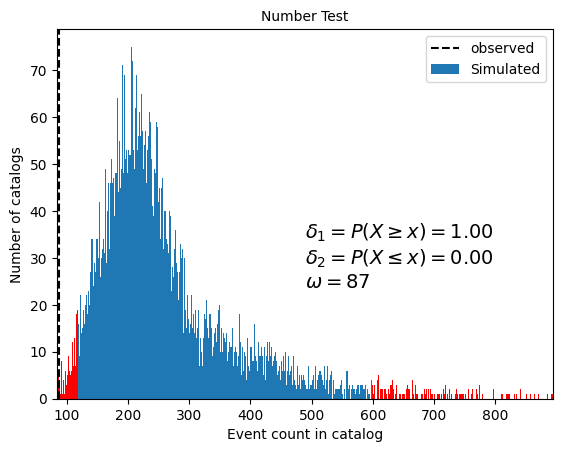

In [29]:
number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),                   
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False
)
ax= number_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'n_test.pdf')

M-test

In [30]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 10,
    'dmw': 0.01
}

magnitude_bins, distribution = catalog_tests.compute_magnitude_distribution(
    forecast[0].mag.cpu().numpy(), 
   **config_dict
)

In [31]:
get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu())),
    verbose=False
)


/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:423: SyntaxWarning: invalid escape sequence '\l'
  ylabel = plot_args.get('ylabel', '$P(X \leq x)$')
/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:1106: SyntaxWarning: invalid escape sequence '\d'
  '$\delta_1 = P(X \geq x) = {:.2f}$\n$\delta_2 = P(X \leq x) = {:.2f}$\n$\omega = {:d}$'
/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:1113: SyntaxWarning: invalid escape sequence '\g'
  ax.annotate('$\gamma = P(X \leq x) = {:.2f}$\n$\omega = {:.2f}$'
/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:1205: SyntaxWarning: invalid escape sequence '\g'
  ax.annotate('$\gamma = P(X \geq x) = {:.2f}$\n$\omega = {:.2f}$'
/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:1213: SyntaxWarning: invalid escape sequence '\g'
  ax.annotate('$\gamma = P(X \geq x) = {:.2f}$\n$\omega = {:.2f}$'
/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:1281: Syntax

IndexError: index -1 is out of bounds for axis 0 with size 0

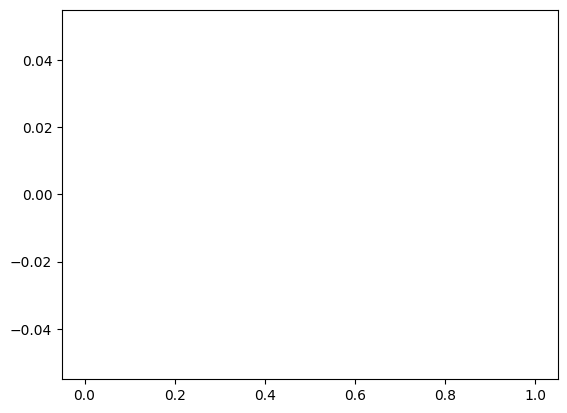

In [32]:
magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
   obs_name='observed',
    sim_name='Simulated',
    plot=False
)
magnitude_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'m_test.pdf')

In [ ]:
checkpoint_dir

PosixPath('../checkpoints/rtpp_20251125-223019')